In [1]:
import pandas as pd
import numpy as np

from dataclasses import replace

In [2]:
as_of = "2026-05-09"

In [3]:
from src.client_policy import mexican_moderate_aggressive_growth_policy

from src.research.macro_liquidity import (
    EconomicSeriesSpec,
    ProviderCredentials,
    ProviderConfig,
    ProviderRegistry,
    MacroLiquidityWorkflow,
    ScenarioOverride,
)

from src.research.macro_liquidity import (
    MacroLiquidityPolicy,
    DataPolicy,
    ValidationPolicy,
    ConfidencePolicy,
    ForecastPolicy,
    ScenarioPolicy,
    AuditPolicy,
)

from src.research.macro_liquidity import (
    default_us_macro_liquidity_catalog,
)

from src.strategy import build_selection_context

In [4]:
credentials = ProviderCredentials()

config = ProviderConfig()

registry = ProviderRegistry.default_us(config=config)

## Indicadores

In [5]:
# HUMANO: define universo metodológico inicial.
specs = default_us_macro_liquidity_catalog()

In [6]:
macro_specs = (
    # empleo
    EconomicSeriesSpec(
        "bls_unemployment_rate",
        "macro",
        "labor",
        False,
        provider="BLS",
        provider_code="LNS14000000",
        frequency="M",
        transform="level",
        periods=1,
        weight=1.2,
        required=True,
    ),
    
    EconomicSeriesSpec(
        "bls_nonfarm_payrolls",
        "macro",
        "labor",
        True,
        provider="BLS",
        provider_code="CES0000000001",
        frequency="M",
        transform="yoy_change",
        periods=12,
    ),
    


    # política fiscal
    EconomicSeriesSpec(
        "federal_surplus_deficit_gdp",
        "macro",
        "fiscal_policy",
        True,
        provider="FRED",
        provider_code="FYFSGDA188S",
        frequency="Q",
        transform="level",
        periods=1,
    ),
    EconomicSeriesSpec(
        "federal_debt_public_gdp",
        "macro",
        "fiscal_policy",
        False,
        provider="FRED",
        provider_code="GFDEGDQ188S",
        frequency="Q",
        transform="level",
        periods=1,
    ),
    EconomicSeriesSpec(
        "federal_current_expenditures",
        "macro",
        "fiscal_policy",
        True,
        provider="FRED",
        provider_code="FGEXPND",
        frequency="Q",
        transform="yoy_change",
        periods=4,
    ),

    # vivienda
    EconomicSeriesSpec(
        "housing_starts",
        "macro",
        "housing",
        True,
        provider="FRED",
        provider_code="HOUST",
        frequency="M",
        transform="yoy_change",
        periods=12,
    ),
    EconomicSeriesSpec(
        "building_permits",
        "macro",
        "housing",
        True,
        provider="FRED",
        provider_code="PERMIT",
        frequency="M",
        transform="yoy_change",
        periods=12,
    ),
    EconomicSeriesSpec(
        "case_shiller_home_price_index",
        "macro",
        "housing",
        True,
        provider="FRED",
        provider_code="CSUSHPISA",
        frequency="M",
        transform="yoy_change",
        periods=12,
    ),
    EconomicSeriesSpec(
        "mortgage_30y_rate",
        "macro",
        "housing",
        False,
        provider="FRED",
        provider_code="MORTGAGE30US",
        frequency="W",
        transform="level",
        periods=1,
    ),

    # energía
    EconomicSeriesSpec(
        "wti_crude_oil",
        "macro",
        "energy",
        False,
        provider="FRED",
        provider_code="DCOILWTICO",
        frequency="D",
        transform="yoy_change",
        periods=252,
    ),
    EconomicSeriesSpec(
        "regular_gasoline_price",
        "macro",
        "energy",
        False,
        provider="FRED",
        provider_code="GASREGW",
        frequency="W",
        transform="yoy_change",
        periods=52,
    ),
    EconomicSeriesSpec(
        "cpi_energy",
        "macro",
        "energy",
        False,
        provider="FRED",
        provider_code="CPIENGSL",
        frequency="M",
        transform="yoy_change",
        periods=12,
    ),

    # expectativas
    EconomicSeriesSpec(
        "consumer_sentiment",
        "macro",
        "expectations",
        True,
        provider="FRED",
        provider_code="UMCSENT",
        frequency="M",
        transform="level",
        periods=1,
        weight=1.1,
    ),
    EconomicSeriesSpec(
        "michigan_inflation_expectations",
        "macro",
        "expectations",
        False,
        provider="FRED",
        provider_code="MICH",
        frequency="M",
        transform="level",
        periods=1,
    ),
    EconomicSeriesSpec(
        "five_year_breakeven_inflation",
        "macro",
        "expectations",
        False,
        provider="FRED",
        provider_code="T5YIE",
        frequency="D",
        transform="level",
        periods=1,
    ),
)


In [7]:
specs = list(specs)

specs.extend(macro_specs)
specs

[EconomicSeriesSpec(name='fred_real_gdp', engine='macro', block='growth', higher_is_better=True, provider='FRED', provider_code='GDPC1', frequency='Q', transform='yoy_change', periods=4, weight=1.2, required=True, description='', provider_params={}),
 EconomicSeriesSpec(name='fred_industrial_production', engine='macro', block='growth', higher_is_better=True, provider='FRED', provider_code='INDPRO', frequency='M', transform='yoy_change', periods=12, weight=1.0, required=False, description='', provider_params={}),
 EconomicSeriesSpec(name='fred_retail_sales', engine='macro', block='growth', higher_is_better=True, provider='FRED', provider_code='RSXFS', frequency='M', transform='yoy_change', periods=12, weight=1.0, required=False, description='', provider_params={}),
 EconomicSeriesSpec(name='fred_real_pce', engine='macro', block='consumer', higher_is_better=True, provider='FRED', provider_code='PCEC96', frequency='M', transform='yoy_change', periods=12, weight=1.0, required=False, descri

In [8]:
series_data = registry.fetch(
    specs, 
    start="2010-01-01", 
    end="2026-05-09"
)

In [9]:
provider_errors = registry.error_report()
provider_errors

,provider,series,error_type,message


In [ ]:
series_data.series.unique()

<StringArray>
[           'bls_nonfarm_payrolls',           'bls_unemployment_rate',
                'building_permits',   'case_shiller_home_price_index',
              'consumer_sentiment',                      'cpi_energy',
    'federal_current_expenditures',         'federal_debt_public_gdp',
     'federal_surplus_deficit_gdp',   'five_year_breakeven_inflation',
                'fred_bank_credit',               'fred_broad_dollar',
                   'fred_ci_loans',                   'fred_core_cpi',
                   'fred_core_pce',                        'fred_cpi',
                 'fred_fed_assets',             'fred_fed_funds_rate',
                     'fred_hy_oas',      'fred_industrial_production',
             'fred_initial_claims',                      'fred_kcfsi',
                       'fred_nfci',           'fred_nonfarm_payrolls',
            'fred_personal_income',                   'fred_real_gdp',
                   'fred_real_pce',           'fred_reserve_bal

## Politica Metodologica

Data Policy

In [ ]:
data_policy = DataPolicy(
    data_mode="revised",
    real_time_safe=False,
    canonical_frequency ="M",
    quarterly_interpolation= "linear"
)

El validation policy estable como se puede 

In [11]:
validation_policy = ValidationPolicy(
    min_history_months=48,
    max_missing_ratio=0.25,
    min_signal_stability= 0.5,
    candidate_weight_multiplier= 0.6
)

Cuando hablamos de confianza hablamos de que tan confiable es el diagnostico actual dado la cobertura de datos, coherencia de señalres, estabilidad reciente, frescura de datos y consistencia narrativa entre macro y liquidez

In [ ]:
# confience_policy = ConfidencePolicy(
#   coverage_weight=
# )

Selección de modelos y regimenes esperados

In [ ]:
forecast_policy = ForecastPolicy(
    benchmark_model="ar1",
    diagnostic_benchmark_models=("naive", "drift"),
    candidate_models=("mean_reversion", "ets", "auto_sarima"),
    selection_metric="rmse",
    min_improvement_over_benchmark=0.02,
    rolling_initial_train_months=60,
    rolling_forecast_horizon=12,
    max_cv_folds=24,
    sarima_max_models=12,
)

MacroLiquidityPolicy no descarga datos, no clasifica regimenes y no escoge activos por si sola. Es el objeto de gobierno metodologico que controla como se tratan los datos, como se validan las series, como se calcula la confianza, como compiten los modelos de la series de tiempo, como se asignan probabilidades de escenarios y donde queda la auditoria.



In [12]:
policy = MacroLiquidityPolicy(
    validation = validation_policy,
    forecast   = forecast_policy
)

In [13]:
policy.methodology_summary()

{'data_mode': 'revised',
 'real_time_safe': False,
 'canonical_frequency': 'M',
 'rebalance_frequency': 'Q',
 'quarterly_interpolation': 'linear',
 'forecast_horizons_months': (3, 12, 6),
 'base_horizon_months': 3,
 'strategic_horizon_months': 12,
 'fallback_horizon_months': 6,
 'benchmark_model': 'ar1',
 'diagnostic_benchmark_models': ('mean', 'naive', 'drift'),
 'candidate_models': ('mean_reversion', 'ets', 'auto_sarima', 'bootstrap_ar1'),
 'selection_metric': 'rmse',
 'min_improvement_over_benchmark': 0.03,
 'rolling_initial_train_months': 36,
 'rolling_forecast_horizon': 3,
 'run_root': 'data/research_runs'}

In [14]:
workflow = MacroLiquidityWorkflow(specs, policy=policy, min_periods=6)

In [15]:
overrides = [
    # ScenarioOverride(
    #     scenario_name="downside",
    #     probability=0.30,
    #     rationale="Credit spreads widening faster than model baseline.",
    #     approved_by="investment_committee",
    # )
]

In [16]:
result = workflow.run(
    series_data=series_data,
    as_of=as_of,
    client_policy=mexican_moderate_aggressive_growth_policy(),
    scenario_overrides=overrides,
    provider_errors=provider_errors,
    write_audit=True,
)

In [17]:
tables = result.summary_tables()

<Axes: xlabel='date'>

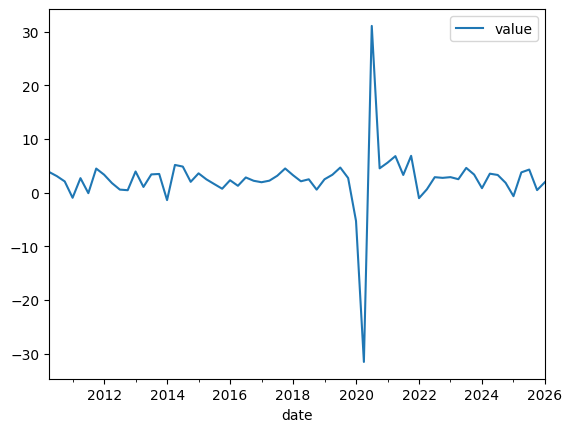

In [42]:
returns_real_gdp = series_data.loc[
    series_data["series"] == "fred_real_gdp", 
    ["date", "value"]
    ].set_index(keys = "date").pct_change().dropna() * 4 * 100

returns_real_gdp.plot()

In [18]:
tables["feature_validation"]

,series,engine,block,role,history_months,missing_ratio,methodology_weight,status,effective_weight,reason
0,fred_real_gdp,macro,growth,coincident,0,1.0,1.2,candidate,0.72,insufficient_history_or_missing_data
1,fred_industrial_production,macro,growth,coincident,195,0.0,1.0,active,1.00,passes_validation
2,fred_retail_sales,macro,growth,coincident,195,0.0,1.0,active,1.00,passes_validation
3,fred_real_pce,macro,consumer,coincident,195,0.0,1.0,active,1.00,passes_validation
4,fred_personal_income,macro,consumer,coincident,195,0.0,1.0,active,1.00,passes_validation
5,fred_saving_rate,macro,consumer,coincident,195,0.0,1.0,active,1.00,passes_validation
6,fred_cpi,macro,inflation,coincident,195,0.0,1.2,active,1.20,passes_validation
7,fred_core_cpi,macro,inflation,coincident,195,0.0,1.0,active,1.00,passes_validation
8,fred_core_pce,macro,inflation,coincident,195,0.0,1.0,active,1.00,passes_validation
9,fred_unemployment_rate,macro,labor,coincident,196,0.0,1.2,active,1.20,passes_validation


In [19]:
tables["nowcast_confidence"].T

,0
date,2026-05-31 00:00:00
coverage,0.928571
agreement,0.428571
stability,0.905435
freshness,0.98
narrative_coherence,1.0
macro_liquidity_contradiction,False
confidence,0.81123
block_count,9


In [ ]:
tables["nowcast_contributors"]

,date,engine,block,series,signal,signed_zscore,weight,contribution
0,2026-05-31,macro,policy,fred_ten_year_yield,4.410000,-1.723364,1.0,-1.723364
1,2026-05-31,liquidity,fed_liquidity,fred_fed_assets,-0.242761,-1.627863,1.0,-1.627863
2,2026-05-31,macro,policy,fred_two_year_yield,3.920000,-1.437873,1.0,-1.437873
3,2026-05-31,macro,expectations,five_year_breakeven_inflation,2.620000,-1.431109,1.0,-1.431109
4,2026-05-31,liquidity,fed_liquidity,fred_reserve_balances,-0.201146,-1.083765,1.2,-1.300518
5,2026-05-31,liquidity,treasury_liquidity,fred_tga,877761.000000,-1.207045,1.0,-1.207045
6,2026-05-31,macro,energy,regular_gasoline_price,0.321853,-0.782479,1.0,-0.782479
7,2026-05-31,liquidity,global_dollar_liquidity,fred_broad_dollar,118.392600,-0.768778,1.0,-0.768778
8,2026-05-31,liquidity,fed_liquidity,fred_reverse_repo,0.787000,0.599143,1.0,0.599143
9,2026-05-31,liquidity,financial_conditions,fred_hy_oas,2.790000,0.978287,0.6,0.586972


In [21]:
tables["forecast_diagnostics"]

,target,model,benchmark_model,accepted,acceptance_reason,observations,rolling_rmse,rolling_mae,directional_accuracy,benchmark_rmse,...,rmse,mae,residual_std,ewma_residual_volatility,aic,bic,acf_lag_1,acf_lag_3,acf_lag_6,acf_lag_12
0,consumer_score,ets,ar1,True,candidate_selected_after_beating_benchmark_in_...,190,0.078851,0.060742,0.666667,0.334362,...,0.619976,0.326134,0.619976,0.278856,-173.668151,-160.680055,0.611448,0.376357,0.294074,-0.156916
1,credit_score,ar1,ar1,False,benchmark_selected_candidates_did_not_clear_im...,139,0.526198,0.324075,0.625000,0.526198,...,0.203832,0.119083,0.203832,0.213679,-43.339090,-37.484583,0.974471,0.872011,0.739132,0.523596
2,energy_score,ar1,ar1,False,benchmark_selected_candidates_did_not_clear_im...,180,0.435643,0.323906,0.791667,0.435643,...,0.326828,0.251825,0.326828,0.292273,111.621324,117.996095,0.951007,0.811619,0.681218,0.471771
3,expectations_score,ar1,ar1,False,benchmark_selected_candidates_did_not_clear_im...,192,0.651274,0.453436,0.458333,0.651274,...,0.368196,0.269951,0.368196,0.313836,164.363135,170.867682,0.948862,0.881862,0.796534,0.610308
4,fed_liquidity_score,ar1,ar1,False,benchmark_selected_candidates_did_not_clear_im...,183,0.224434,0.152183,0.666667,0.224434,...,0.781121,0.408283,0.781121,0.213340,430.576627,436.984640,0.684726,0.637194,0.403895,0.157088
5,financial_conditions_score,ar1,ar1,False,benchmark_selected_candidates_did_not_clear_im...,192,0.427250,0.318795,0.666667,0.427250,...,0.480318,0.279159,0.480318,0.334762,265.911366,272.415913,0.854932,0.533097,0.327231,-0.042357
6,funding_score,ar1,ar1,False,benchmark_selected_candidates_did_not_clear_im...,93,0.106487,0.086591,1.000000,0.106487,...,0.409275,0.187359,0.409275,0.126858,100.705162,105.748739,0.960350,0.908402,0.757152,0.374480
7,global_dollar_liquidity_score,ar1,ar1,False,benchmark_selected_candidates_did_not_clear_im...,192,0.268782,0.201846,0.541667,0.268782,...,0.378273,0.239895,0.378273,0.154865,174.677785,181.182332,0.924456,0.846535,0.736098,0.516242
8,growth_score,auto_sarima,ar1,True,candidate_selected_after_beating_benchmark_in_...,178,0.167552,0.128554,0.708333,0.214161,...,0.576627,0.340225,0.576625,0.271829,295.683156,308.106938,0.831468,0.544165,0.389485,-0.140598
9,housing_score,auto_sarima,ar1,True,candidate_selected_after_beating_benchmark_in_...,191,0.216040,0.155497,0.708333,0.295435,...,0.355048,0.251963,0.354842,0.250796,93.004059,102.549410,0.932760,0.822030,0.657151,0.400532


In [22]:
tables["scenario_table"]

,name,macro_regime,liquidity_regime,probability,horizon_months,confidence,rationale
0,base,estanflacion,neutral,0.569628,3,0.565427,Highest-probability model-implied regime at th...
1,upside,expansion_desinflacionaria,neutral,0.165186,3,0.452341,Upper-bound forecast path with better macro/li...
2,downside,estanflacion,restrictiva,0.265186,3,0.452341,Lower-bound forecast path with weaker macro/li...


In [23]:
tables["asset_view"].T

,0
current_stance,treasuries
expected_stance,defensivos
final_stance,defensivos
current_weight,0.4
expected_weight,0.6
overweights,"defensive_equity, cash_like"
underweights,"cyclicals, high_yield"
preferred_styles,"low_volatility, quality"
risk_controls,liquidity_filter
rationale,Forward-looking regime receives the larger tac...


In [24]:
tables["selection_context"].T

,0
current_macro_regime,recesion_desinflacionaria
current_liquidity_regime,neutral
expected_macro_regime,estanflacion
expected_liquidity_regime,neutral
base_currency,MXN
risk_profile,moderate_aggressive
horizon_years,10.0
asset_class_overweights,"defensive_equity, cash_like"
asset_class_underweights,"cyclicals, high_yield"
preferred_styles,"low_volatility, quality"
